### Установка зависимостей



```bash
!pip install -U torch torchaudio soundfile scikit-learn tqdm matplotlib
```

### Импорт библиотек

In [1]:
import os, glob, random, json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchaudio
import soundfile as sf

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt

# Для воспроизводимости
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

### Загрузка датасета (RAVDESS)

Ниже код ожидает, что у тебя есть папка `data/RAVDESS`, внутри которой лежат `Actor_XX/*.wav`.

Файлы RAVDESS имеют имя вида `03-01-05-01-02-02-12.wav`, где **третий блок** — код эмоции.

**Эмоции (RAVDESS):**
- 1 neutral
- 2 calm
- 3 happy
- 4 sad
- 5 angry
- 6 fearful
- 7 disgust
- 8 surprised


In [ ]:
DATA_ROOT = r"data/RAVDESS"  

EMOTION_ID_TO_NAME = {
    1: "neutral",
    2: "calm",
    3: "happy",
    4: "sad",
    5: "angry",
    6: "fearful",
    7: "disgust",
    8: "surprised",
}
USED_EMOTIONS = sorted(list(EMOTION_ID_TO_NAME.keys()))

def parse_ravdess_emotion_id(filepath: str) -> int:
    name = os.path.basename(filepath)
    parts = name.replace(".wav", "").split("-")
    return int(parts[2])

files = glob.glob(os.path.join(DATA_ROOT, "**", "*.wav"), recursive=True)
files = [p for p in files if parse_ravdess_emotion_id(p) in USED_EMOTIONS]

len(files), files[0] if files else None

(2880, 'data/RAVDESS\\Actor_01\\03-01-01-01-01-01-01.wav')

### Визуализация датасета

Посмотрим распределение классов. Это важно, потому что **дисбаланс** может привести к тому, что модель будет 'любить' самые частые эмоции.

Ниже — простой график частот.

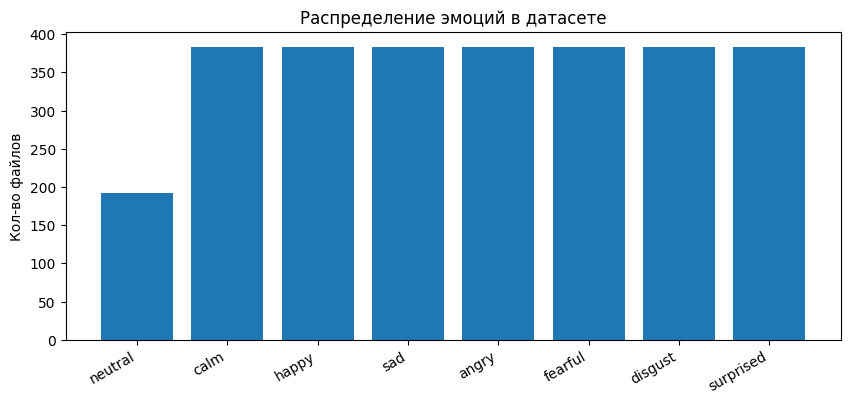

Counter({2: 384, 3: 384, 4: 384, 5: 384, 6: 384, 7: 384, 8: 384, 1: 192})

In [3]:
from collections import Counter

emotion_ids = [parse_ravdess_emotion_id(p) for p in files]
cnt = Counter(emotion_ids)

labels = [EMOTION_ID_TO_NAME[i] for i in sorted(cnt.keys())]
values = [cnt[i] for i in sorted(cnt.keys())]

plt.figure(figsize=(10,4))
plt.bar(labels, values)
plt.xticks(rotation=30, ha="right")
plt.title("Распределение эмоций в датасете")
plt.ylabel("Кол-во файлов")
plt.show()

cnt

**Краткий вывод по распределению классов:**  
- Если один класс доминирует, модель будет чаще предсказывать его.  
- При дисбалансе используйте `class_weights` и/или аугментации для редких классов.

### Предобработка: чтение аудио, ресэмплинг, MFCC



In [4]:
SAMPLE_RATE = 16000
N_MFCC = 40
MAX_SECONDS = 3.5
MAX_LEN = int(SAMPLE_RATE * MAX_SECONDS)

mfcc_transform = torchaudio.transforms.MFCC(
    sample_rate=SAMPLE_RATE,
    n_mfcc=N_MFCC,
    melkwargs={
        "n_fft": 1024,
        "hop_length": 320,
        "win_length": 1024,
        "n_mels": 64,
        "center": True,
    },
)

def load_wav_soundfile(path: str, target_sr: int = SAMPLE_RATE) -> torch.Tensor:
    data, sr = sf.read(path, always_2d=True)   # [time, channels]
    wav = torch.from_numpy(data.T).float()     # -> [channels, time]
    wav = wav.mean(dim=0, keepdim=True)        # mono [1, time]
    if sr != target_sr:
        wav = torchaudio.functional.resample(wav, sr, target_sr)
    wav = wav / (wav.abs().max() + 1e-9)
    return wav

def fix_length(wav: torch.Tensor, max_len: int = MAX_LEN) -> torch.Tensor:
    cur = wav.shape[-1]
    if cur > max_len:
        return wav[..., :max_len]
    if cur < max_len:
        return F.pad(wav, (0, max_len-cur))
    return wav

# Пример: вытащим MFCC одного файла
example_path = files[0]
wav = fix_length(load_wav_soundfile(example_path))
feat = mfcc_transform(wav)  # [1, n_mfcc, T]
wav.shape, feat.shape

(torch.Size([1, 56000]), torch.Size([1, 40, 176]))

### Спектрограммы и MFCC для разных эмоций

Показаны примеры: **waveform**, **Mel-spectrogram** и **MFCC** (по одному файлу на эмоцию).  
После каждого примера печатаются краткие наблюдения по спектральной картине.


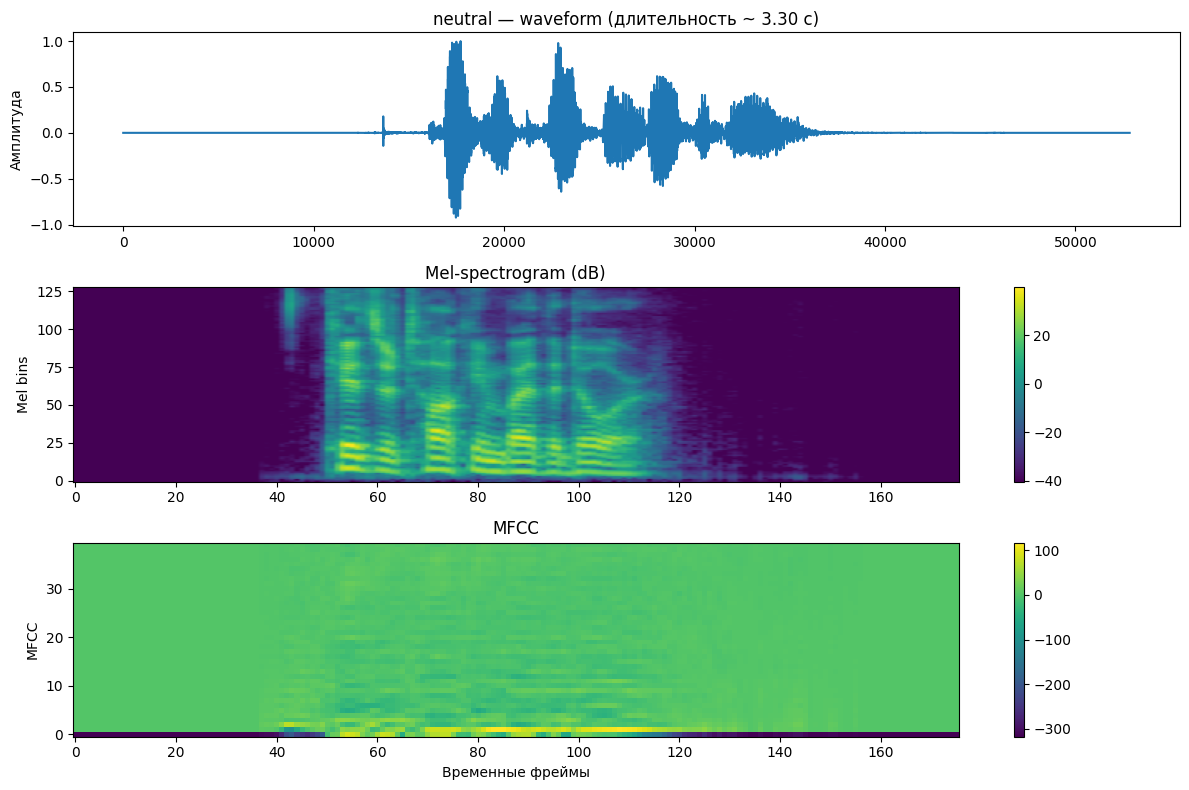

[neutral] 03-01-01-01-01-01-01.wav
• Энергия сильнее выражена в низких частотах; контраст ≈ 18.96.
• MFCC: заметные изменения по времени обычно отражают изменения тембра/артикуляции.



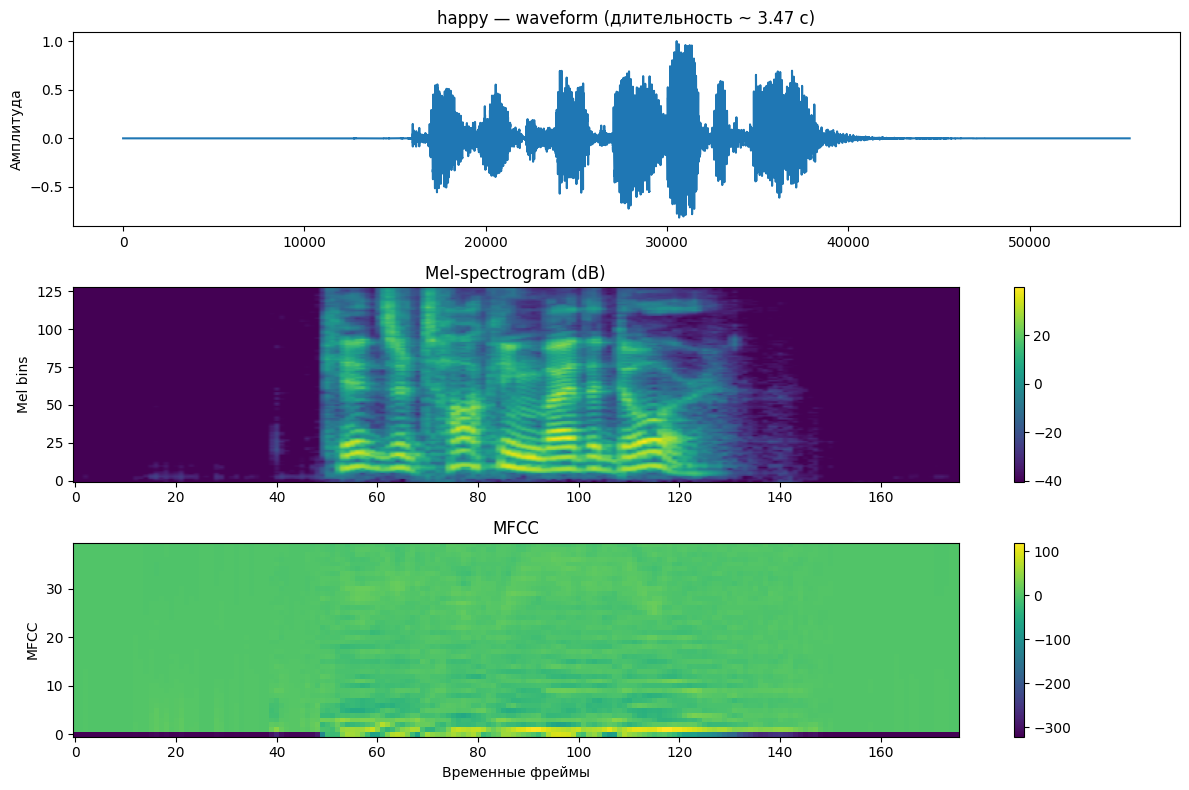

[happy] 03-01-03-01-01-01-01.wav
• Энергия сильнее выражена в низких частотах; контраст ≈ 19.63.
• MFCC: заметные изменения по времени обычно отражают изменения тембра/артикуляции.



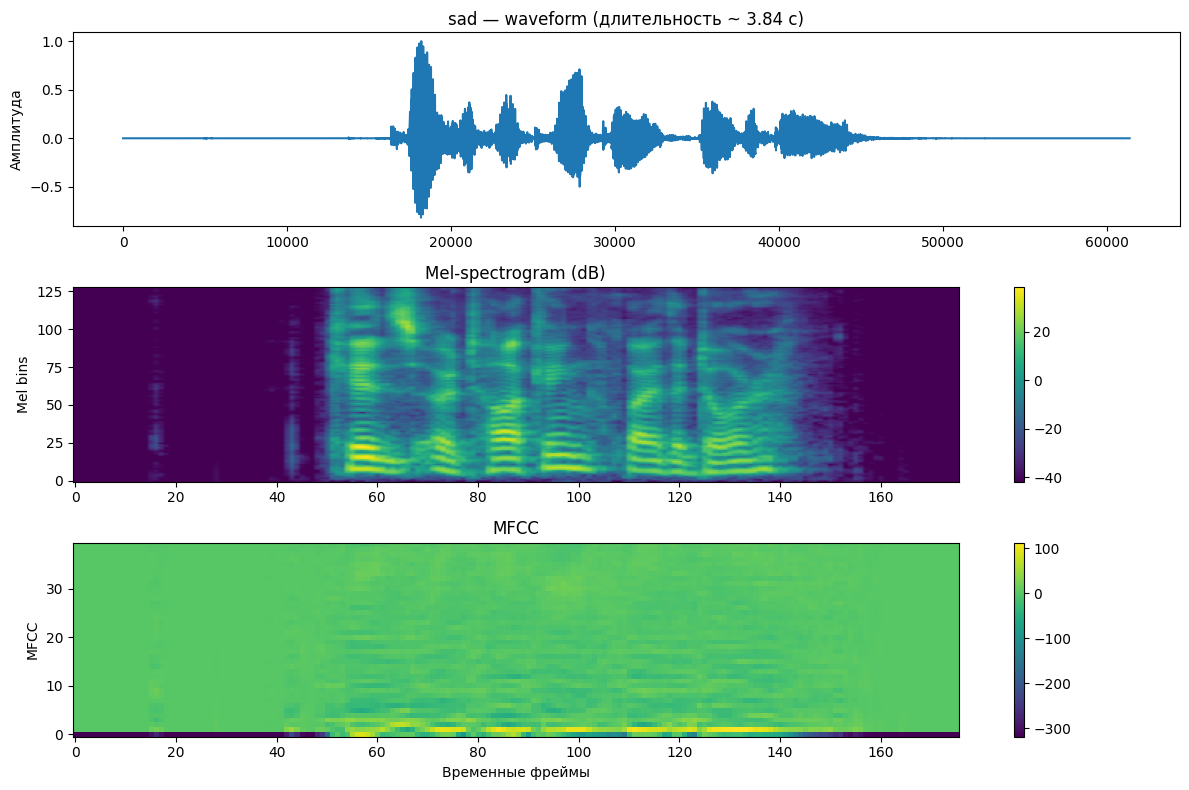

[sad] 03-01-04-01-01-01-01.wav
• Энергия сильнее выражена в низких частотах; контраст ≈ 18.30.
• MFCC: заметные изменения по времени обычно отражают изменения тембра/артикуляции.



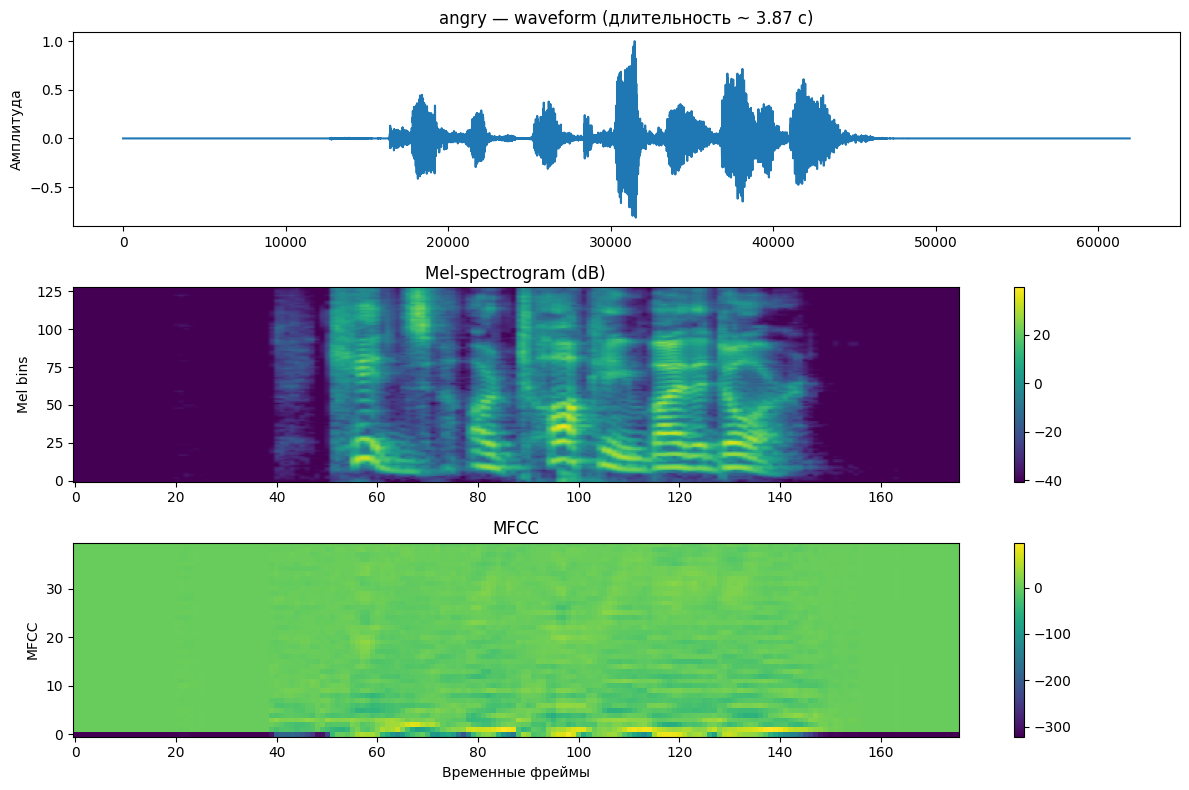

[angry] 03-01-05-01-01-01-01.wav
• Энергия сильнее выражена в низких частотах; контраст ≈ 19.11.
• MFCC: заметные изменения по времени обычно отражают изменения тембра/артикуляции.



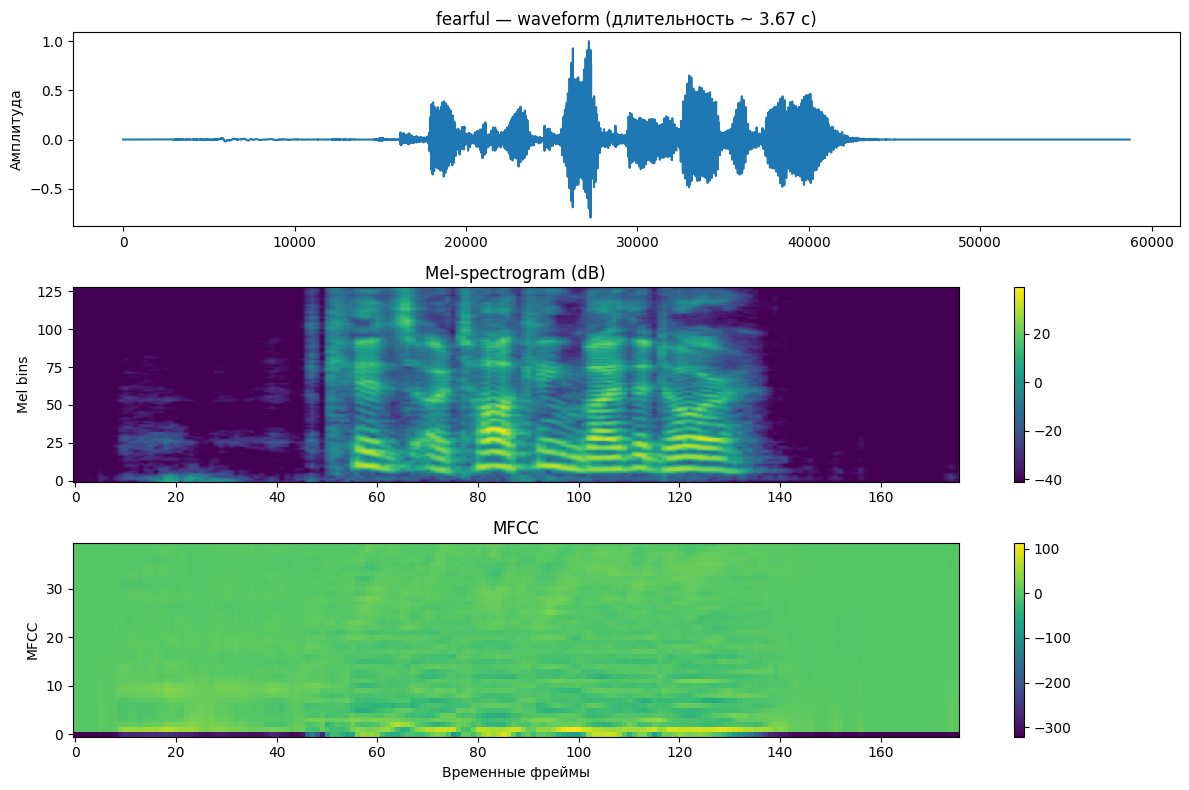

[fearful] 03-01-06-01-01-01-01.wav
• Энергия сильнее выражена в низких частотах; контраст ≈ 18.86.
• MFCC: заметные изменения по времени обычно отражают изменения тембра/артикуляции.



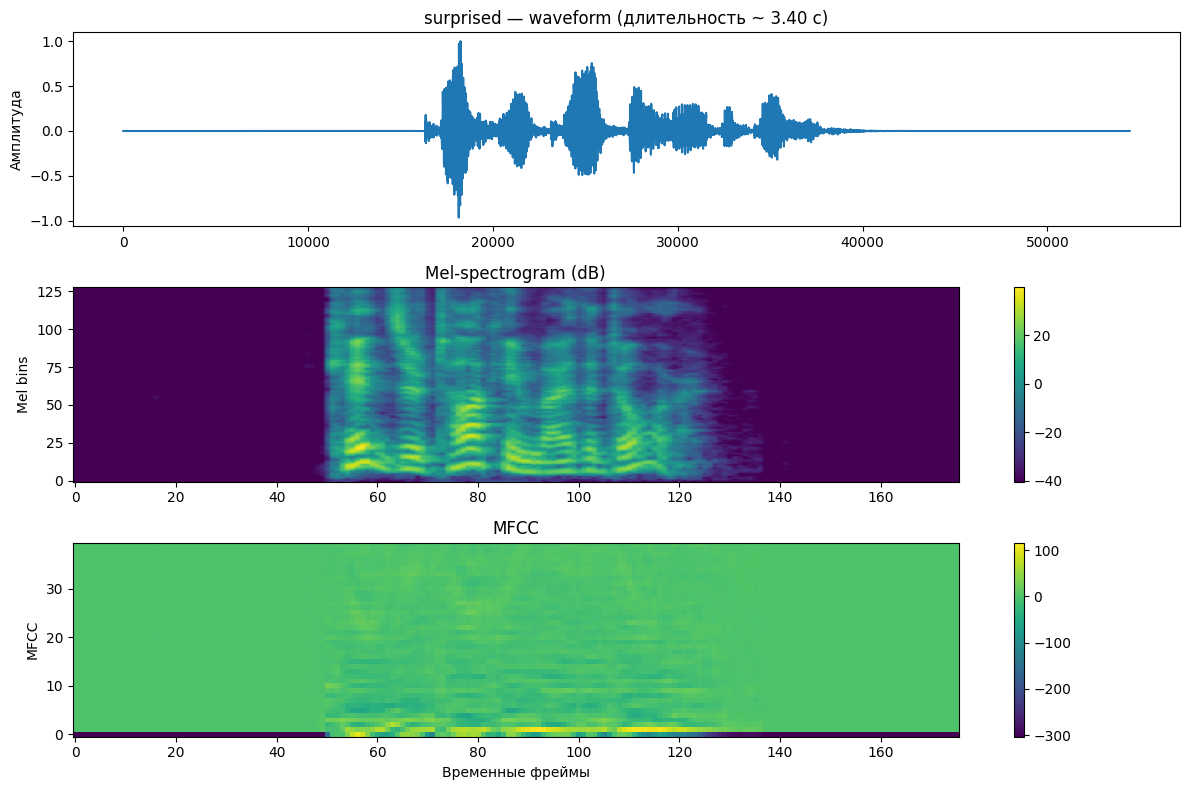

[surprised] 03-01-08-01-01-01-01.wav
• Энергия сильнее выражена в низких частотах; контраст ≈ 18.16.
• MFCC: заметные изменения по времени обычно отражают изменения тембра/артикуляции.



In [5]:
# Доп. преобразования для визуализации
mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=SAMPLE_RATE,
    n_fft=1024,
    hop_length=320,
    win_length=1024,
    n_mels=128,
    center=True,
)
to_db = torchaudio.transforms.AmplitudeToDB(stype="power", top_db=80)

# По одному примеру для выбранных эмоций
picked_emotions = [1, 3, 4, 5, 6, 8]  # neutral, happy, sad, angry, fearful, surprised
emo_to_path = {}

for emo in picked_emotions:
    for p in files:
        if parse_ravdess_emotion_id(p) == emo:
            emo_to_path[emo] = p
            break

def quick_spec_notes(mel_db: torch.Tensor) -> str:
    '''
    Короткие заметки по mel-спектрограмме:
    - где больше энергии (низы/середина/верха)
    - контраст (условно: вариативность по времени)
    '''
    m = mel_db.squeeze(0)  # [n_mels, T]
    mean_by_mel = m.mean(dim=1)

    n = len(mean_by_mel)
    low = mean_by_mel[:n//3].mean().item()
    mid = mean_by_mel[n//3: 2*n//3].mean().item()
    high = mean_by_mel[2*n//3:].mean().item()

    contrast = m.std(dim=1).mean().item()
    band = max([("низких", low), ("средних", mid), ("высоких", high)], key=lambda x: x[1])[0]
    return f"Энергия сильнее выражена в {band} частотах; контраст ≈ {contrast:.2f}."

import matplotlib.pyplot as plt

for emo, p in emo_to_path.items():
    wav_raw = load_wav_soundfile(p)
    wav = fix_length(wav_raw)

    mel = mel_transform(wav)
    mel_db = to_db(mel)
    mfcc = mfcc_transform(wav)

    name = EMOTION_ID_TO_NAME[emo]
    dur = wav_raw.shape[-1] / SAMPLE_RATE

    plt.figure(figsize=(12, 8))

    plt.subplot(3, 1, 1)
    plt.plot(wav_raw.squeeze(0).numpy())
    plt.title(f"{name} — waveform (длительность ~ {dur:.2f} c)")
    plt.ylabel("Амплитуда")

    plt.subplot(3, 1, 2)
    plt.imshow(mel_db.squeeze(0).numpy(), aspect="auto", origin="lower")
    plt.title("Mel-spectrogram (dB)")
    plt.ylabel("Mel bins")
    plt.colorbar()

    plt.subplot(3, 1, 3)
    plt.imshow(mfcc.squeeze(0).numpy(), aspect="auto", origin="lower")
    plt.title("MFCC")
    plt.xlabel("Временные фреймы")
    plt.ylabel("MFCC")
    plt.colorbar()

    plt.tight_layout()
    plt.show()

    print(f"[{name}] {os.path.basename(p)}")
    print("•", quick_spec_notes(mel_db))
    print("• MFCC: заметные изменения по времени обычно отражают изменения тембра/артикуляции.\n")


### Визуализация признаков (MFCC)

Нарисуем MFCC-карту для одного примера. По горизонтали — время (фреймы), по вертикали — MFCC-коэффициенты.

Это помогает убедиться, что признаки считаются корректно.

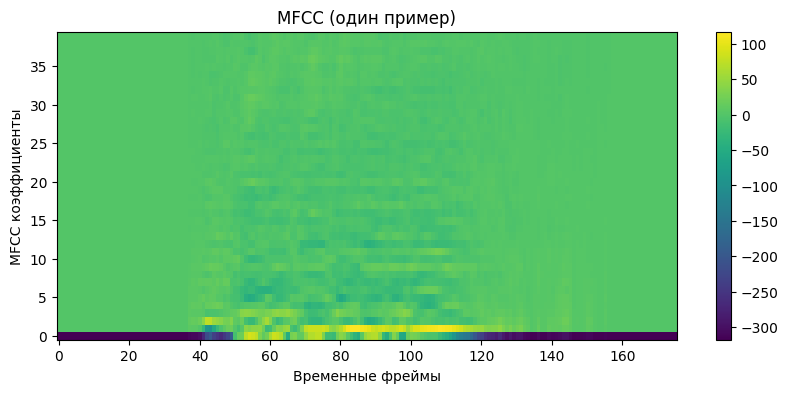

In [ ]:
plt.figure(figsize=(10,4))
plt.imshow(feat.squeeze(0).numpy(), aspect="auto", origin="lower")
plt.title("MFCC ")
plt.xlabel("Временные фреймы")
plt.ylabel("MFCC коэффициенты")
plt.colorbar()
plt.show()

**Краткий вывод по MFCC:**  
- MFCC сжимают спектральную информацию в компактный набор признаков.  
- Различия в «рисунке» MFCC по времени помогают отделять эмоции.

### Dataset и DataLoader





In [ ]:
class SpeechEmotionDataset(Dataset):
    def __init__(self, paths, labels):
        self.paths = paths
        self.labels = labels

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        y = self.labels[idx]
        wav = fix_length(load_wav_soundfile(path))
        x = mfcc_transform(wav)  # [1, n_mfcc, T]
        x = (x - x.mean()) / (x.std() + 1e-6)
        return x, y

raw_ids = [parse_ravdess_emotion_id(p) for p in files]
unique = sorted(set(raw_ids))
id_to_class = {eid:i for i,eid in enumerate(unique)}
class_names = [EMOTION_ID_TO_NAME[eid] for eid in unique]
labels = [id_to_class[eid] for eid in raw_ids]

X_train, X_val, y_train, y_val = train_test_split(
    files, labels, test_size=0.2, random_state=SEED, stratify=labels
)

train_ds = SpeechEmotionDataset(X_train, y_train)
val_ds = SpeechEmotionDataset(X_val, y_val)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=0, pin_memory=False)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False, num_workers=0, pin_memory=False)

len(train_ds), len(val_ds), class_names

(2304,
 576,
 ['neutral',
  'calm',
  'happy',
  'sad',
  'angry',
  'fearful',
  'disgust',
  'surprised'])

### Модель: CNN + BiGRU



In [8]:
class CNNBiGRU(nn.Module):
    def __init__(self, n_classes: int, n_mfcc: int = N_MFCC):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d((2,2)),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d((2,2)),
        )
        self.gru_hidden = 128
        self.gru = nn.GRU(
            input_size=64 * (n_mfcc // 4),
            hidden_size=self.gru_hidden,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )
        self.head = nn.Sequential(
            nn.Linear(self.gru_hidden*2, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        # x: [B,1,n_mfcc,T]
        z = self.cnn(x)             # [B,64,mfcc',T']
        b,c,mf,t = z.shape
        z = z.permute(0,3,1,2).contiguous()  # [B,T',C,mfcc']
        z = z.view(b,t,c*mf)                 # [B,T',C*mfcc']
        z,_ = self.gru(z)                    # [B,T',2H]
        z = z.mean(dim=1)                    # pooling
        return self.head(z)

model = CNNBiGRU(n_classes=len(class_names)).to(device)
sum(p.numel() for p in model.parameters())

644296

### Обучение

Обучим модель и сохраним историю `loss/accuracy`, чтобы потом построить графики.



In [9]:
def train_one_epoch(model, loader, optim):
    model.train()
    total_loss = 0.0
    y_true, y_pred = [], []
    for x,y in loader:
        x,y = x.to(device), y.to(device)
        optim.zero_grad(set_to_none=True)
        logits = model(x)
        loss = F.cross_entropy(logits, y)
        loss.backward()
        optim.step()
        total_loss += loss.item() * x.size(0)
        y_true += y.detach().cpu().tolist()
        y_pred += logits.argmax(1).detach().cpu().tolist()
    return total_loss/len(loader.dataset), accuracy_score(y_true, y_pred)

@torch.no_grad()
def eval_one_epoch(model, loader):
    model.eval()
    total_loss = 0.0
    y_true, y_pred = [], []
    for x,y in loader:
        x,y = x.to(device), y.to(device)
        logits = model(x)
        loss = F.cross_entropy(logits, y)
        total_loss += loss.item() * x.size(0)
        y_true += y.detach().cpu().tolist()
        y_pred += logits.argmax(1).detach().cpu().tolist()
    return total_loss/len(loader.dataset), accuracy_score(y_true, y_pred), y_true, y_pred

optim = torch.optim.AdamW(model.parameters(), lr=1e-3)

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

EPOCHS = 20
best_val = 0.0
best_path = "best_emotion_model.pt"

for epoch in range(1, EPOCHS+1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optim)
    va_loss, va_acc, _, _ = eval_one_epoch(model, val_loader)

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss)
    history["val_acc"].append(va_acc)

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"train loss {tr_loss:.4f} acc {tr_acc:.3f} | "
          f"val loss {va_loss:.4f} acc {va_acc:.3f}")

    if va_acc > best_val:
        best_val = va_acc
        torch.save({
            "model_state": model.state_dict(),
            "class_names": class_names,
            "sample_rate": SAMPLE_RATE,
            "n_mfcc": N_MFCC,
            "max_seconds": MAX_SECONDS,
        }, best_path)

best_val, best_path

Epoch 01/20 | train loss 1.9009 acc 0.240 | val loss 1.7325 acc 0.319
Epoch 02/20 | train loss 1.5773 acc 0.399 | val loss 1.3749 acc 0.503
Epoch 03/20 | train loss 1.2445 acc 0.527 | val loss 1.0884 acc 0.618
Epoch 04/20 | train loss 0.9528 acc 0.657 | val loss 0.8271 acc 0.675
Epoch 05/20 | train loss 0.7386 acc 0.744 | val loss 0.7331 acc 0.719
Epoch 06/20 | train loss 0.5285 acc 0.816 | val loss 0.4601 acc 0.854
Epoch 07/20 | train loss 0.3681 acc 0.875 | val loss 0.3816 acc 0.865
Epoch 08/20 | train loss 0.2684 acc 0.913 | val loss 0.2972 acc 0.917
Epoch 09/20 | train loss 0.1894 acc 0.934 | val loss 0.2634 acc 0.910
Epoch 10/20 | train loss 0.1347 acc 0.957 | val loss 0.2261 acc 0.934
Epoch 11/20 | train loss 0.1227 acc 0.963 | val loss 0.1369 acc 0.969
Epoch 12/20 | train loss 0.0640 acc 0.984 | val loss 0.2392 acc 0.931
Epoch 13/20 | train loss 0.0760 acc 0.975 | val loss 0.1796 acc 0.941
Epoch 14/20 | train loss 0.0556 acc 0.985 | val loss 0.1954 acc 0.948
Epoch 15/20 | train 

(0.96875, 'best_emotion_model.pt')

### Графики обучения

Посмотрим динамику `loss` и `accuracy`. В идеале `train_loss` и `val_loss` падают, а `val_acc` растёт.

Если `train_acc` растёт, а `val_acc` стоит или падает — это признак **переобучения**.

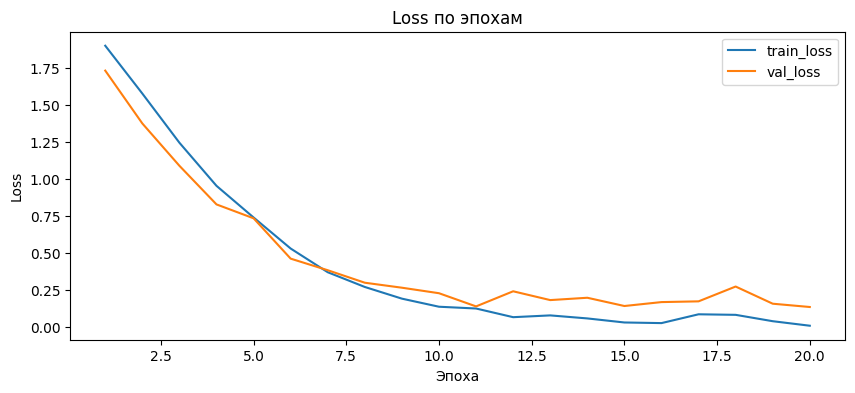

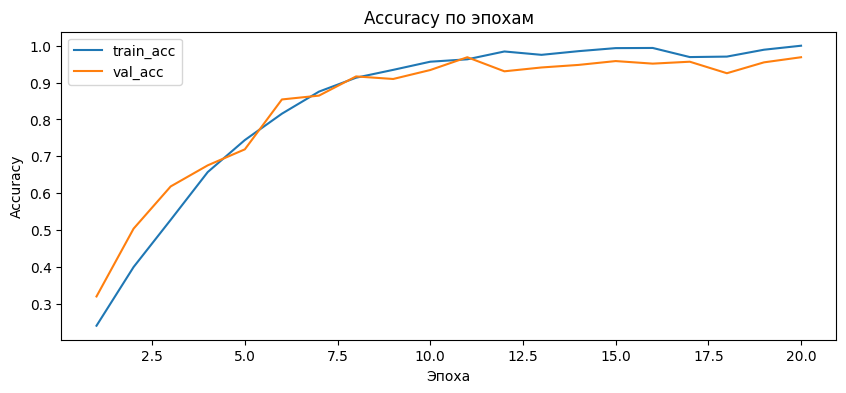

In [10]:
epochs = np.arange(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(10,4))
plt.plot(epochs, history["train_loss"], label="train_loss")
plt.plot(epochs, history["val_loss"], label="val_loss")
plt.title("Loss по эпохам")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(epochs, history["train_acc"], label="train_acc")
plt.plot(epochs, history["val_acc"], label="val_acc")
plt.title("Accuracy по эпохам")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

**Краткий вывод по кривым обучения:**  
- Норма: train и val улучшаются и выходят на плато.  
- Переобучение: train продолжает улучшаться, val ухудшается/стоит.  
- Для стабилизации используйте early stopping и/или аугментации.

### Отчёт качества: confusion matrix + classification report

              precision    recall  f1-score   support

     neutral       0.95      0.95      0.95        38
        calm       0.93      1.00      0.96        76
       happy       0.95      1.00      0.97        77
         sad       0.97      0.92      0.95        77
       angry       1.00      0.97      0.99        77
     fearful       1.00      0.97      0.99        77
     disgust       0.97      0.95      0.96        77
   surprised       0.97      0.97      0.97        77

    accuracy                           0.97       576
   macro avg       0.97      0.97      0.97       576
weighted avg       0.97      0.97      0.97       576



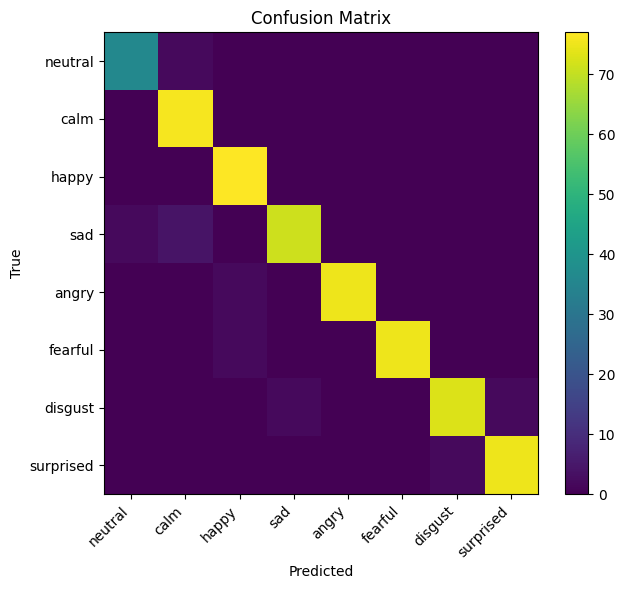

In [ ]:
# лучший чекпоинт и оценка
ckpt = torch.load(best_path, map_location=device)
model.load_state_dict(ckpt["model_state"])
model.eval()

_, _, y_true, y_pred = eval_one_epoch(model, val_loader)

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7,6))
plt.imshow(cm, aspect="auto", origin="upper")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.xticks(range(len(class_names)), class_names, rotation=45, ha="right")
plt.yticks(range(len(class_names)), class_names)
plt.show()

**Как читать confusion matrix:**

- Диагональ — правильные ответы.
- Вне диагонали — где модель путается.
- Если, например, `sad` часто предсказывается как `neutral`, это может означать, что признаков MFCC недостаточно, или что в датасете эти эмоции похожи по интонации.

Для улучшения можно попробовать заменить MFCC на лог-мел спектрограммы или взять предобученную модель (wav2vec2/HuBERT) + небольшой классификатор.

### Экспорт модели (как файл + метаданные)

Мы уже сохранили лучший чекпоинт `best_emotion_model.pt`. Ниже — минимальный пример, как загрузить и предсказывать эмоцию для одного файла.

In [12]:
def predict_emotion(path: str):
    ckpt = torch.load(best_path, map_location=device)
    model = CNNBiGRU(n_classes=len(ckpt["class_names"])).to(device)
    model.load_state_dict(ckpt["model_state"])
    model.eval()

    wav = fix_length(load_wav_soundfile(path))
    x = mfcc_transform(wav)
    x = (x - x.mean()) / (x.std() + 1e-6)
    x = x.unsqueeze(0).to(device)  # [1,1,n_mfcc,T]

    with torch.no_grad():
        logits = model(x)
        pred = logits.softmax(dim=1).cpu().numpy()[0]
    idx = int(pred.argmax())
    return ckpt["class_names"][idx], pred

# Пример
pred_name, prob = predict_emotion(files[0])
pred_name, prob

('neutral',
 array([9.57002461e-01, 3.11385691e-02, 4.07516304e-03, 7.57806795e-03,
        2.18857031e-06, 1.11635076e-04, 8.10529018e-05, 1.08695049e-05],
       dtype=float32))